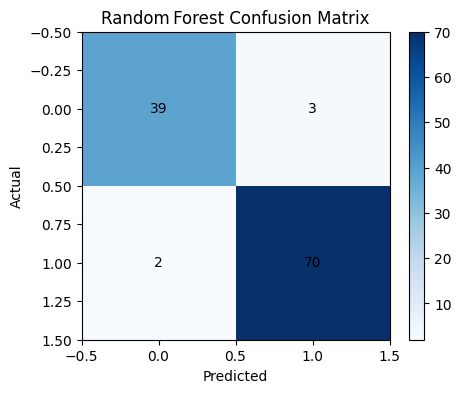

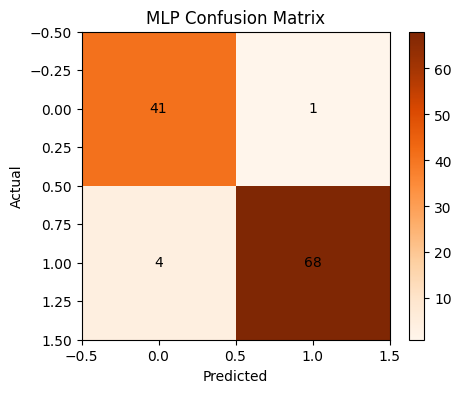

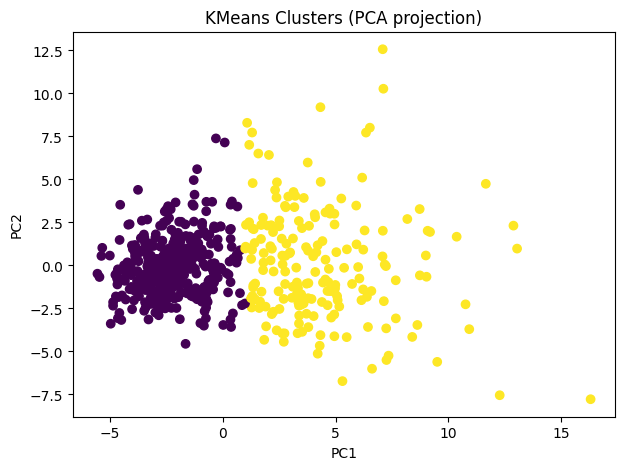

RF accuracy: 0.956140350877193
MLP accuracy: 0.956140350877193
         mean radius  mean texture  mean perimeter  mean area  malignant_rate
cluster                                                                      
0             12.340         17.72           79.01     466.70           0.904
1             17.505         21.05          115.55     953.35           0.093


In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt

data = load_breast_cancer(as_frame=True)
df = pd.concat([data.data, data.target.rename("target")], axis=1)

X = df.drop(columns=["target"])
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cr_rf = classification_report(y_test, y_pred_rf, digits=3)

plt.figure(figsize=(5,4))
plt.imshow(cm_rf, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        plt.text(j, i, cm_rf[i, j], ha="center", va="center")
plt.colorbar()
plt.show()

mlp = MLPClassifier(hidden_layer_sizes=(32,16), max_iter=300, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
acc_mlp = accuracy_score(y_test, y_pred_mlp)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
cr_mlp = classification_report(y_test, y_pred_mlp, digits=3)

plt.figure(figsize=(5,4))
plt.imshow(cm_mlp, interpolation="nearest", cmap=plt.cm.Oranges)
plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm_mlp.shape[0]):
    for j in range(cm_mlp.shape[1]):
        plt.text(j, i, cm_mlp[i, j], ha="center", va="center")
plt.colorbar()
plt.show()

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df["cluster"] = clusters

pca = PCA(n_components=2, random_state=42)
pc = pca.fit_transform(X_scaled)
plt.figure(figsize=(7,5))
plt.scatter(pc[:,0], pc[:,1], c=clusters, cmap="viridis")
plt.title("KMeans Clusters (PCA projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

cluster_summary = df.groupby("cluster").agg({
    "mean radius":"median",
    "mean texture":"median",
    "mean perimeter":"median",
    "mean area":"median",
    "target": lambda x: round(x.mean(), 3)
}).rename(columns={"target":"malignant_rate"})
print("RF accuracy:", acc_rf)
print("MLP accuracy:", acc_mlp)
print(cluster_summary)
